# 🌾 Seasonal Agriculture Performance Analysis

### Major Project – Data Analytics

**Objective:**  
To analyze agricultural performance across different seasons and identify
meaningful patterns, trends, relationships, variations, and differences
in agricultural performance.

---

### Key Areas of Analysis
- Data Cleaning and Preparation
- Exploratory Data Analysis
- Seasonal Performance
- Environmental Conditions
- Resource Usage
- Crop Performance
- Economic Performance
- Correlation Analysis
- Statistical Analysis
- Outlier Detection
- Findings and Recommendations

In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization style
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
# ==========================================
# UPLOAD DATASET
# ==========================================

from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset (3).csv to seasonal_agriculture_performance_dataset (3) (2).csv


In [9]:
import pandas as pd

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (4000, 28)


In [3]:
# ==========================================
# LOAD DATASET
# ==========================================

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print()
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded successfully!

Number of rows: 4000
Number of columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
# ==========================================
# DATASET INFORMATION
# ==========================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop            

In [5]:
# ==========================================
# MISSING VALUE ANALYSIS
# ==========================================

missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing Percentage": (
        missing.values / len(df) * 100
    ).round(2)
})

missing_table = missing_table.sort_values(
    "Missing Values",
    ascending=False
)

missing_table

,Column,Missing Values,Missing Percentage
6,Rainfall_mm,48,1.2
11,Soil_Moisture_pct,40,1.0
19,Yield_Tonnes_Ha,32,0.8
0,Farm_ID,0,0.0
3,Crop,0,0.0
2,District,0,0.0
5,Farm_Area_Hectares,0,0.0
4,Season,0,0.0
7,Avg_Temperature_C,0,0.0
8,Humidity_pct,0,0.0


In [6]:
# ==========================================
# DUPLICATE RECORDS
# ==========================================

duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


In [7]:
# ==========================================
# DUPLICATE RECORDS
# ==========================================

duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


In [8]:
# ==========================================
# DATA TYPES
# ==========================================

data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

data_types

,Column,Data Type
0,Farm_ID,object
1,State,object
2,District,object
3,Crop,object
4,Season,object
5,Farm_Area_Hectares,float64
6,Rainfall_mm,float64
7,Avg_Temperature_C,float64
8,Humidity_pct,float64
9,Sunlight_Hours_Day,float64


In [9]:
# ==========================================
# UNIQUE VALUES
# ==========================================

for column in df.select_dtypes(include="object").columns:
    print("\n" + "="*50)
    print(column)
    print("="*50)
    print(df[column].unique())


Farm_ID
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

State
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [10]:
# ==========================================
# CATEGORICAL COLUMNS
# ==========================================

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [11]:
# ==========================================
# NUMERICAL COLUMNS
# ==========================================

numerical_columns = df.select_dtypes(
    include=np.number
).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [12]:
# ==========================================
# CHECK NEGATIVE VALUES
# ==========================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns

negative_values = {}

for column in numeric_columns:
    count = (df[column] < 0).sum()
    negative_values[column] = count

negative_table = pd.DataFrame(
    list(negative_values.items()),
    columns=["Column", "Negative Values"]
)

negative_table

,Column,Negative Values
0,Farm_Area_Hectares,0
1,Rainfall_mm,0
2,Avg_Temperature_C,0
3,Humidity_pct,0
4,Sunlight_Hours_Day,0
5,Soil_pH,0
6,Soil_Moisture_pct,0
7,Nitrogen_kg_ha,0
8,Phosphorus_kg_ha,0
9,Potassium_kg_ha,0


In [13]:
# ==========================================
# SEASON DISTRIBUTION
# ==========================================

season_counts = df["Season"].value_counts()

print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


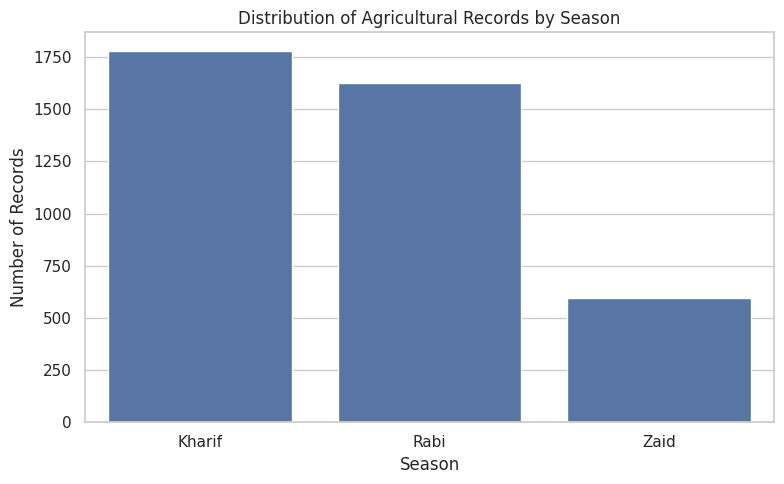

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Season",
    order=df["Season"].value_counts().index
)

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# CROP DISTRIBUTION
# ==========================================

crop_counts = df["Crop"].value_counts()

crop_counts

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


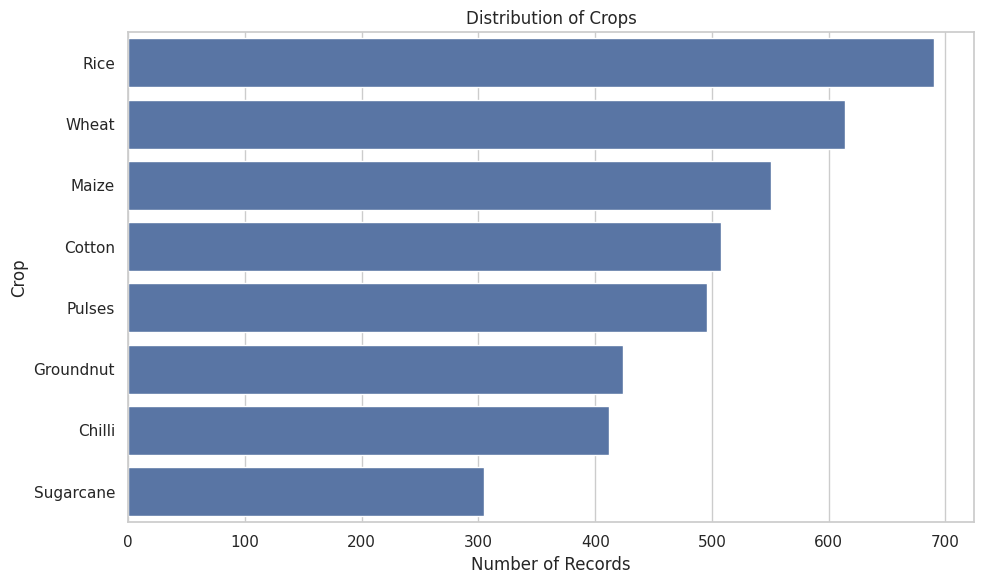

In [16]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="Crop",
    order=df["Crop"].value_counts().index
)

plt.title("Distribution of Crops")
plt.xlabel("Number of Records")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# STATE DISTRIBUTION
# ==========================================

state_counts = df["State"].value_counts()

state_counts

,count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484


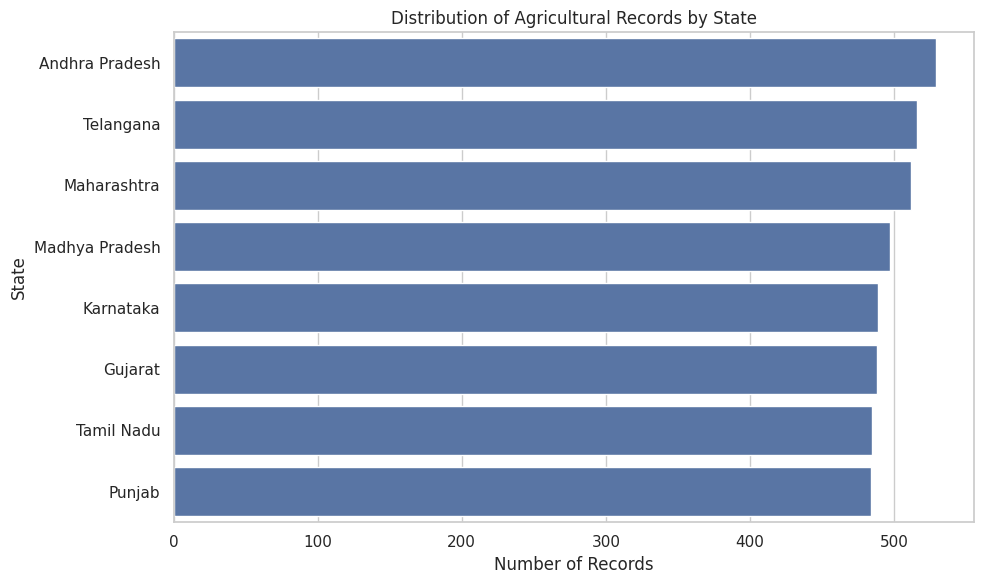

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="State",
    order=df["State"].value_counts().index
)

plt.title("Distribution of Agricultural Records by State")
plt.xlabel("Number of Records")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [19]:
# ==========================================
# AVERAGE YIELD BY SEASON
# ==========================================

yield_by_season = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

yield_by_season

,Yield_Tonnes_Ha
Season,
Kharif,5.643973
Rabi,5.080498
Zaid,4.665942


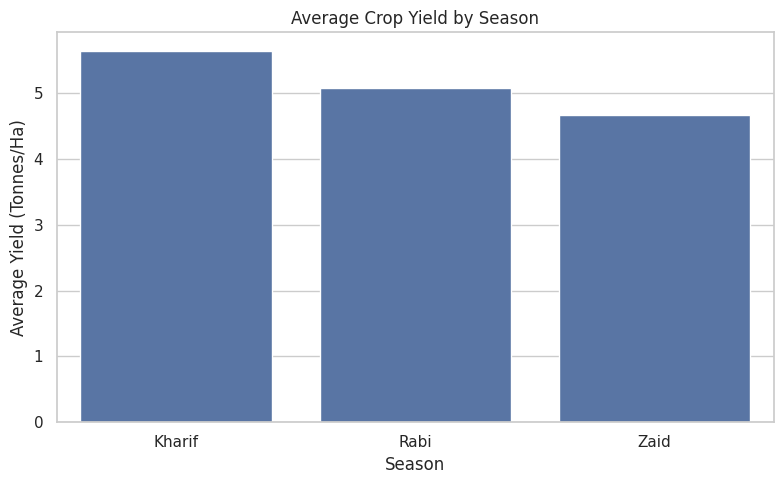

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=yield_by_season.index,
    y=yield_by_season.values
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

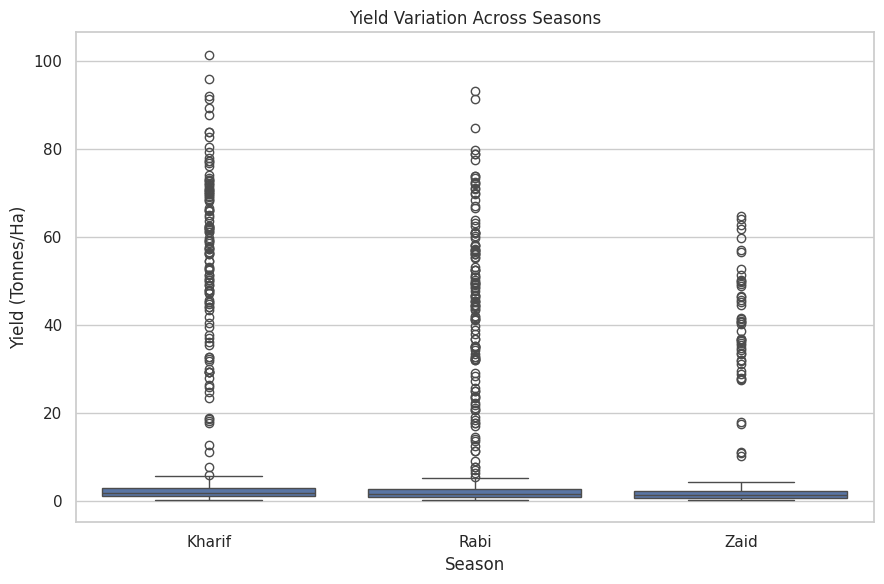

In [21]:
# ==========================================
# YIELD VARIATION BY SEASON
# ==========================================

plt.figure(figsize=(9,6))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Variation Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [22]:
# ==========================================
# PRODUCTION BY SEASON
# ==========================================

production_by_season = (
    df.groupby("Season")["Production_Tonnes"]
    .mean()
    .sort_values(ascending=False)
)

production_by_season

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


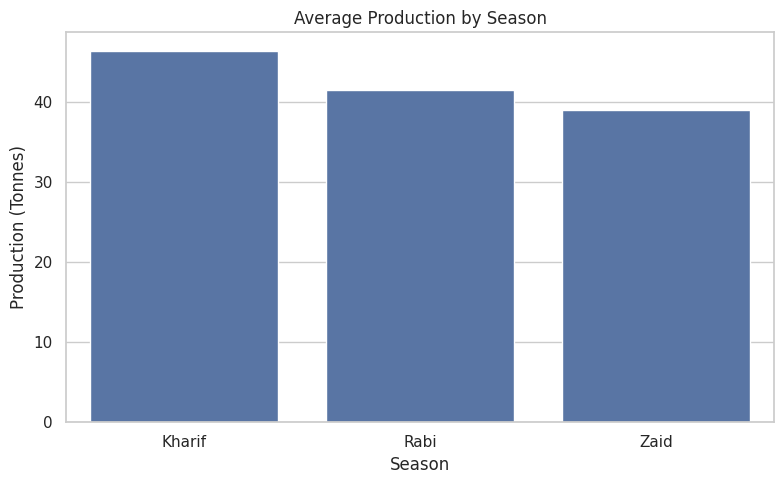

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=production_by_season.index,
    y=production_by_season.values
)

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")

plt.tight_layout()
plt.show()

In [24]:
# ==========================================
# REVENUE BY SEASON
# ==========================================

revenue_by_season = (
    df.groupby("Season")["Revenue_INR"]
    .mean()
    .sort_values(ascending=False)
)

revenue_by_season

,Revenue_INR
Season,
Kharif,710719.055649
Rabi,601526.048556
Zaid,519171.904040


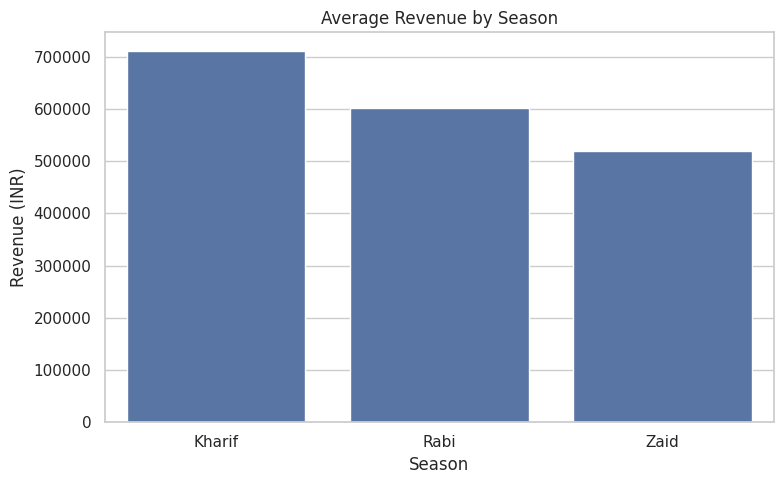

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=revenue_by_season.index,
    y=revenue_by_season.values
)

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Revenue (INR)")

plt.tight_layout()
plt.show()

In [26]:
# ==========================================
# COST BY SEASON
# ==========================================

cost_by_season = (
    df.groupby("Season")["Total_Cost_INR"]
    .mean()
    .sort_values(ascending=False)
)

cost_by_season

,Total_Cost_INR
Season,
Zaid,543976.728956
Kharif,531804.408094
Rabi,513836.578365


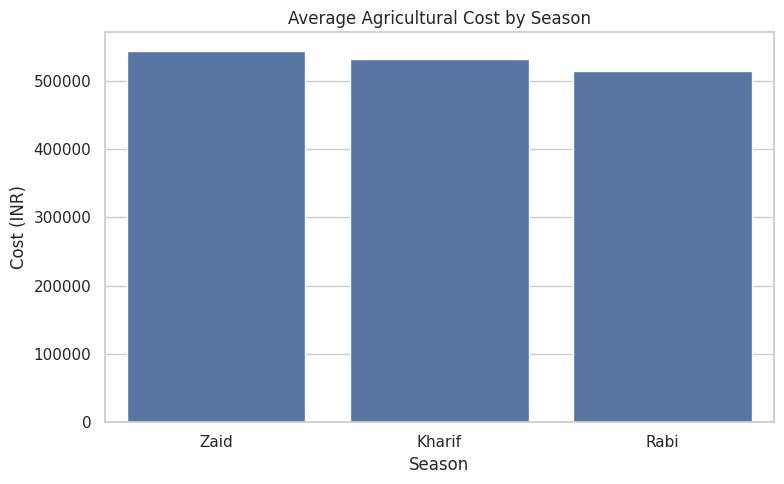

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cost_by_season.index,
    y=cost_by_season.values
)

plt.title("Average Agricultural Cost by Season")
plt.xlabel("Season")
plt.ylabel("Cost (INR)")

plt.tight_layout()
plt.show()

In [28]:
# ==========================================
# PROFIT BY SEASON
# ==========================================

profit_by_season = (
    df.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

profit_by_season

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


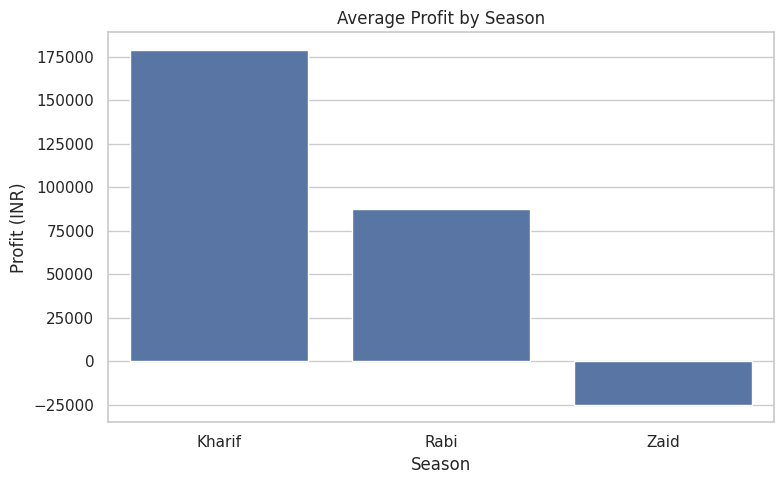

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_by_season.index,
    y=profit_by_season.values
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

In [30]:
# ==========================================
# ECONOMIC PERFORMANCE
# ==========================================

economic = df.groupby("Season")[
    [
        "Revenue_INR",
        "Total_Cost_INR",
        "Profit_INR"
    ]
].mean()

economic

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.055649,531804.408094,178914.647555
Rabi,601526.048556,513836.578365,87689.470191
Zaid,519171.904040,543976.728956,-24804.824916


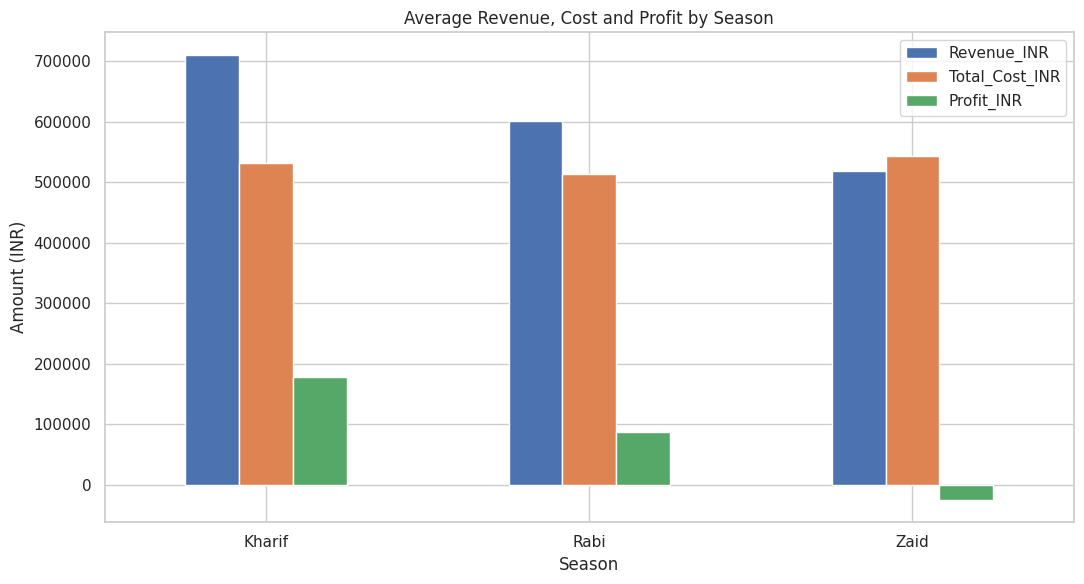

In [31]:
economic.plot(
    kind="bar",
    figsize=(11,6)
)

plt.title("Average Revenue, Cost and Profit by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [32]:
# ==========================================
# RAINFALL BY SEASON
# ==========================================

rainfall = (
    df.groupby("Season")["Rainfall_mm"]
    .mean()
    .sort_values(ascending=False)
)

rainfall

,Rainfall_mm
Season,
Kharif,852.084205
Rabi,436.000124
Zaid,299.421784


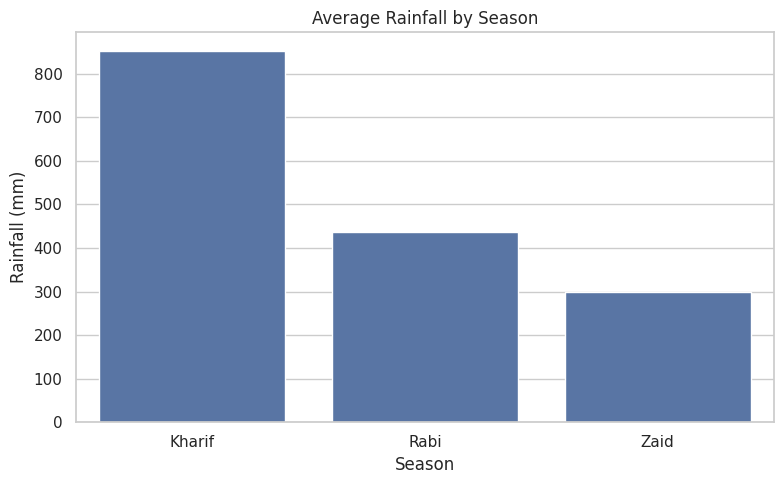

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=rainfall.index,
    y=rainfall.values
)

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.tight_layout()
plt.show()

In [34]:
# ==========================================
# TEMPERATURE BY SEASON
# ==========================================

temperature = (
    df.groupby("Season")["Avg_Temperature_C"]
    .mean()
    .sort_values(ascending=False)
)

temperature

,Avg_Temperature_C
Season,
Zaid,31.042088
Kharif,28.454019
Rabi,23.489183


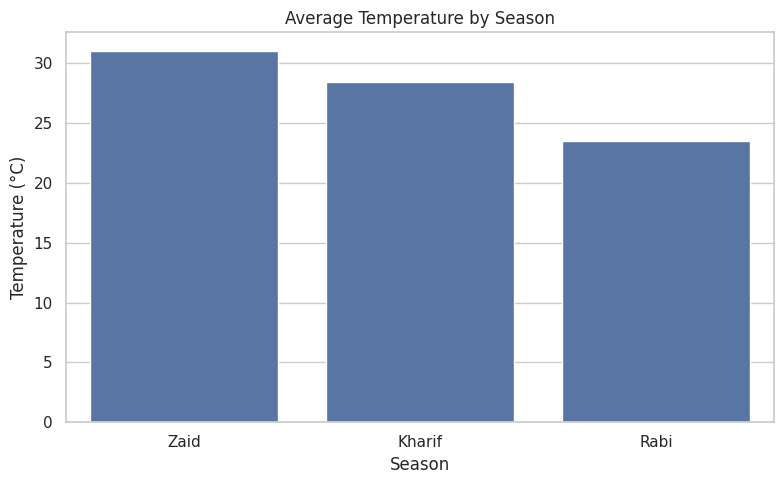

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=temperature.index,
    y=temperature.values
)

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

In [36]:
# ==========================================
# SOIL MOISTURE BY SEASON
# ==========================================

soil_moisture = (
    df.groupby("Season")["Soil_Moisture_pct"]
    .mean()
    .sort_values(ascending=False)
)

soil_moisture

,Soil_Moisture_pct
Season,
Kharif,31.198410
Rabi,24.050620
Zaid,19.170085


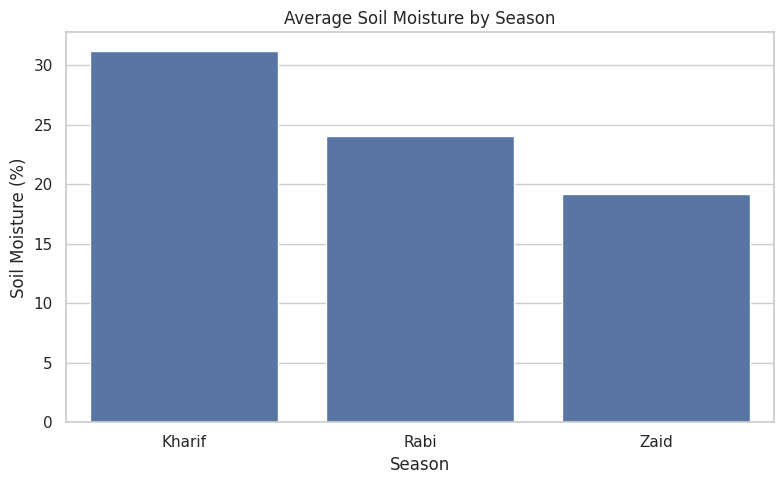

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=soil_moisture.index,
    y=soil_moisture.values
)

plt.title("Average Soil Moisture by Season")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")

plt.tight_layout()
plt.show()

In [38]:
# ==========================================
# WATER USAGE BY SEASON
# ==========================================

water_usage = (
    df.groupby("Season")["Water_Used_m3"]
    .mean()
    .sort_values(ascending=False)
)

water_usage

,Water_Used_m3
Season,
Zaid,6419.893939
Kharif,6102.201237
Rabi,5846.987093


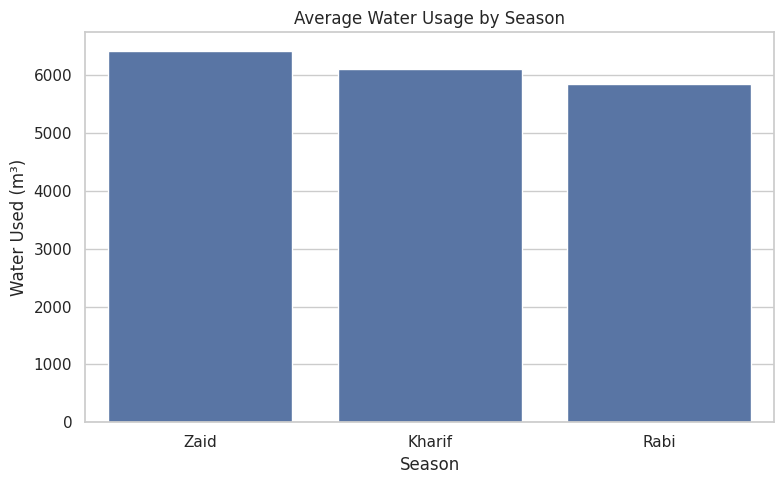

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=water_usage.index,
    y=water_usage.values
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.tight_layout()
plt.show()

In [40]:
# ==========================================
# WATER EFFICIENCY
# ==========================================

water_efficiency = (
    df.groupby("Season")[
        "Water_Efficiency_t_per_1000m3"
    ]
    .mean()
    .sort_values(ascending=False)
)

water_efficiency

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


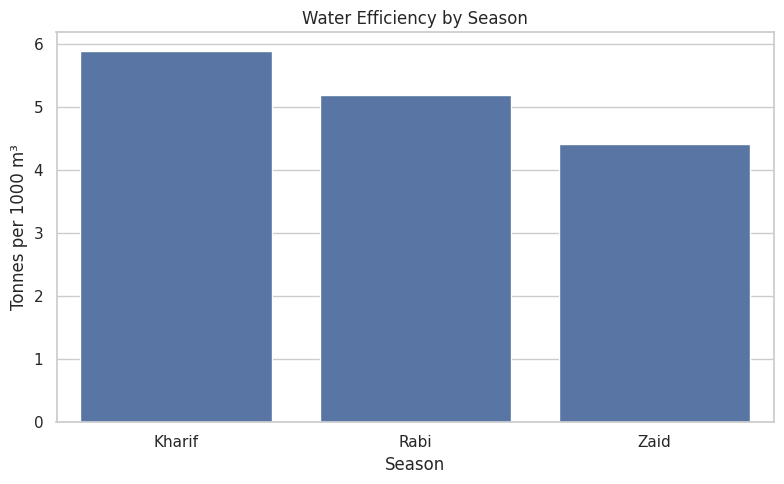

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=water_efficiency.index,
    y=water_efficiency.values
)

plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")

plt.tight_layout()
plt.show()

In [42]:
# ==========================================
# DISEASE / PEST RISK
# ==========================================

risk = (
    df.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

risk

,Disease_Pest_Risk_pct
Season,
Kharif,54.467903
Rabi,40.482114
Zaid,38.216667


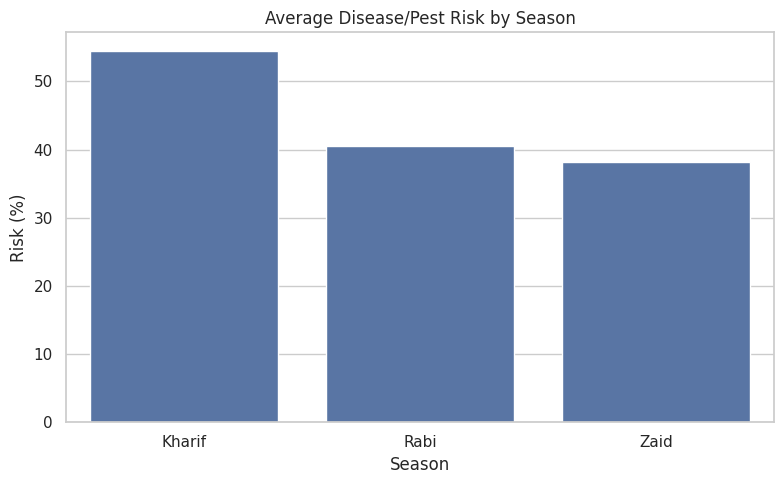

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=risk.index,
    y=risk.values
)

plt.title("Average Disease/Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")

plt.tight_layout()
plt.show()

In [44]:
# ==========================================
# CROP VS SEASON YIELD
# ==========================================

crop_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season_yield.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


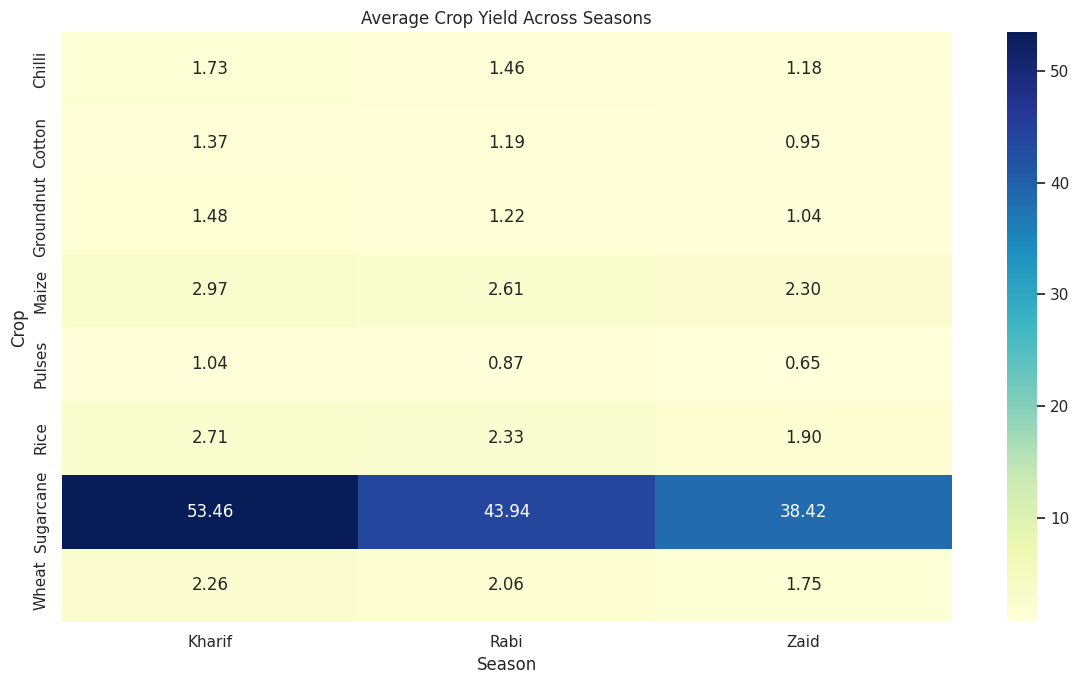

In [45]:
plt.figure(figsize=(12,7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

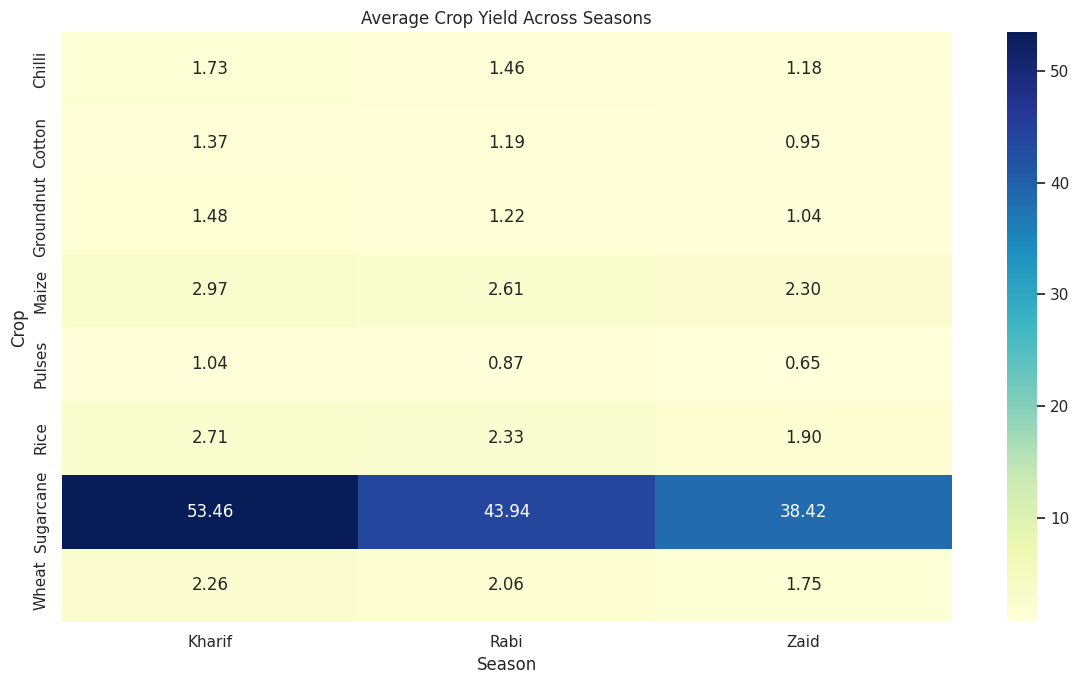

In [46]:
plt.figure(figsize=(12,7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [48]:
# ==========================================
# IRRIGATION METHOD ANALYSIS
# ==========================================

irrigation = df.groupby("Irrigation_Method").agg({
    "Yield_Tonnes_Ha": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
}).round(2)

irrigation

,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,,
Drip,6.62,219626.00,5918.75,6.27
Flood,4.90,73354.02,8026.47,3.44
Rainfed,4.61,79050.37,3549.55,7.56
Sprinkler,5.19,91121.08,6208.26,4.67


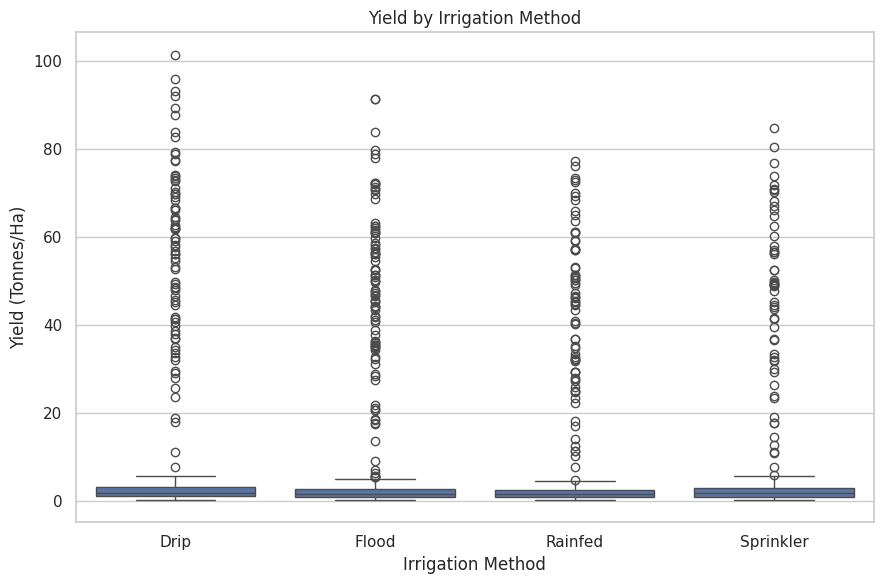

In [49]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

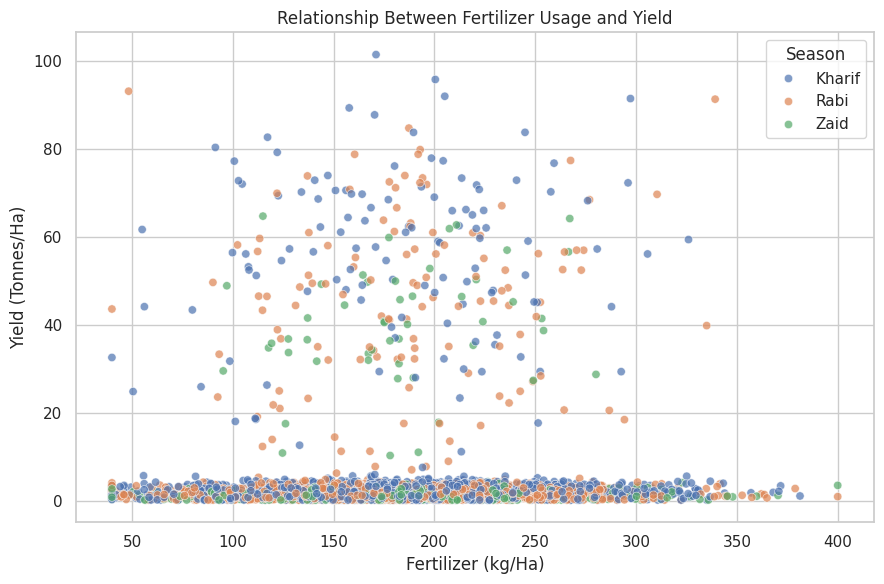

In [50]:
# ==========================================
# FERTILIZER VS YIELD
# ==========================================

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Relationship Between Fertilizer Usage and Yield")
plt.xlabel("Fertilizer (kg/Ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

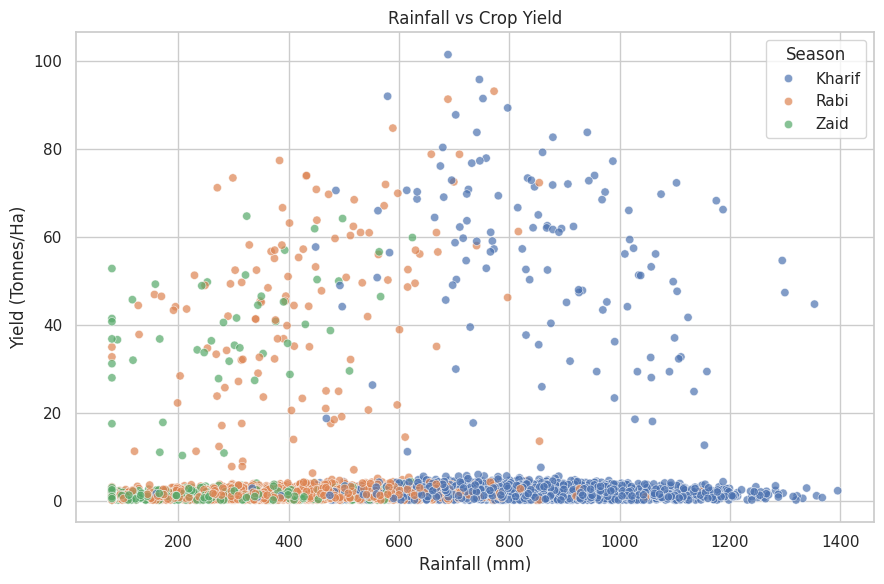

In [51]:
# ==========================================
# RAINFALL VS YIELD
# ==========================================

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

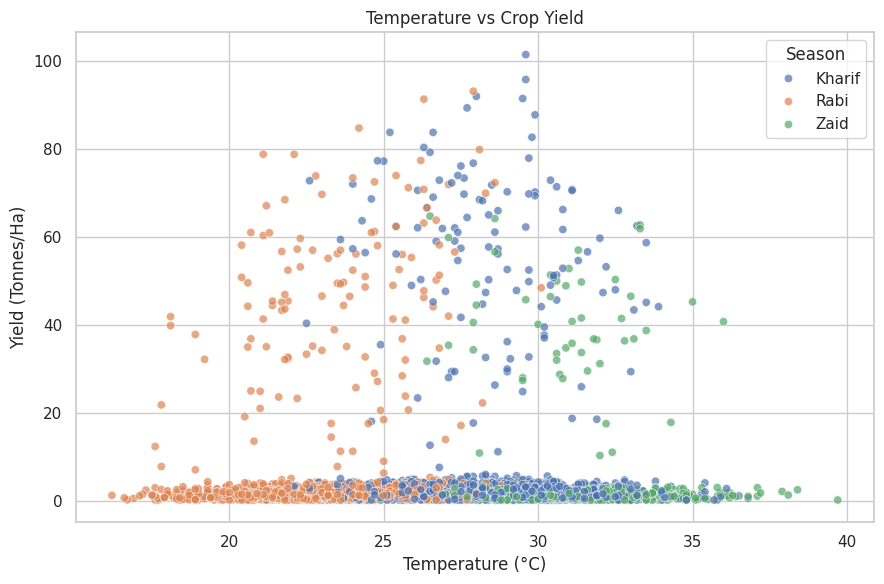

In [52]:
# ==========================================
# TEMPERATURE VS YIELD
# ==========================================

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

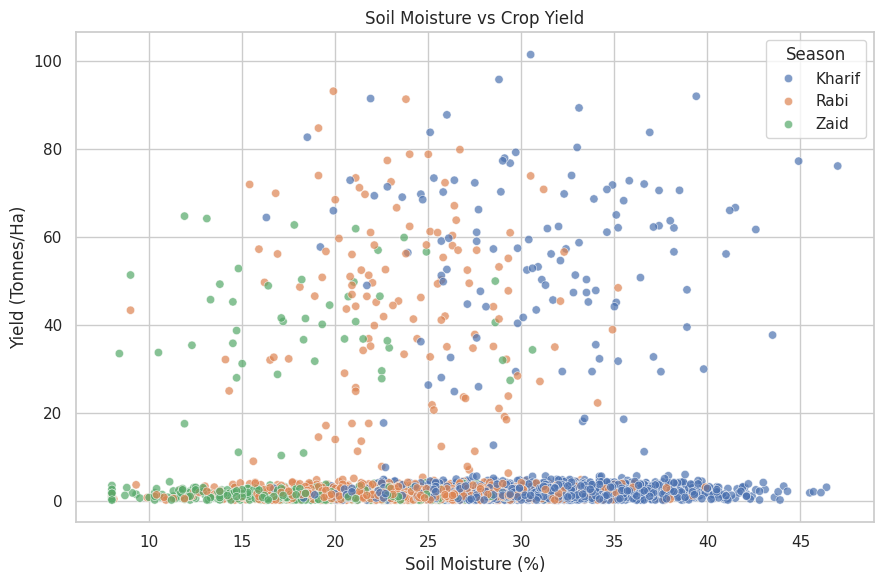

In [53]:
# ==========================================
# SOIL MOISTURE VS YIELD
# ==========================================

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Soil_Moisture_pct",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Soil Moisture vs Crop Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

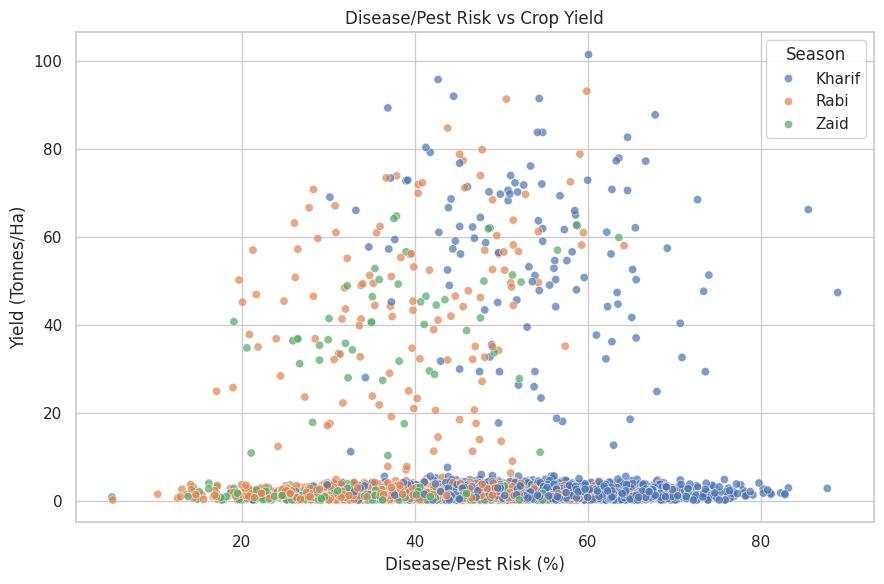

In [54]:
# ==========================================
# DISEASE RISK VS YIELD
# ==========================================

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Disease_Pest_Risk_pct",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Disease/Pest Risk vs Crop Yield")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [55]:
# ==========================================
# CORRELATION ANALYSIS
# ==========================================

numeric_df = df.select_dtypes(
    include=np.number
)

correlation = numeric_df.corr()

correlation.round(2)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,0.01,-0.01,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.52,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.63
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.00,0.52,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01


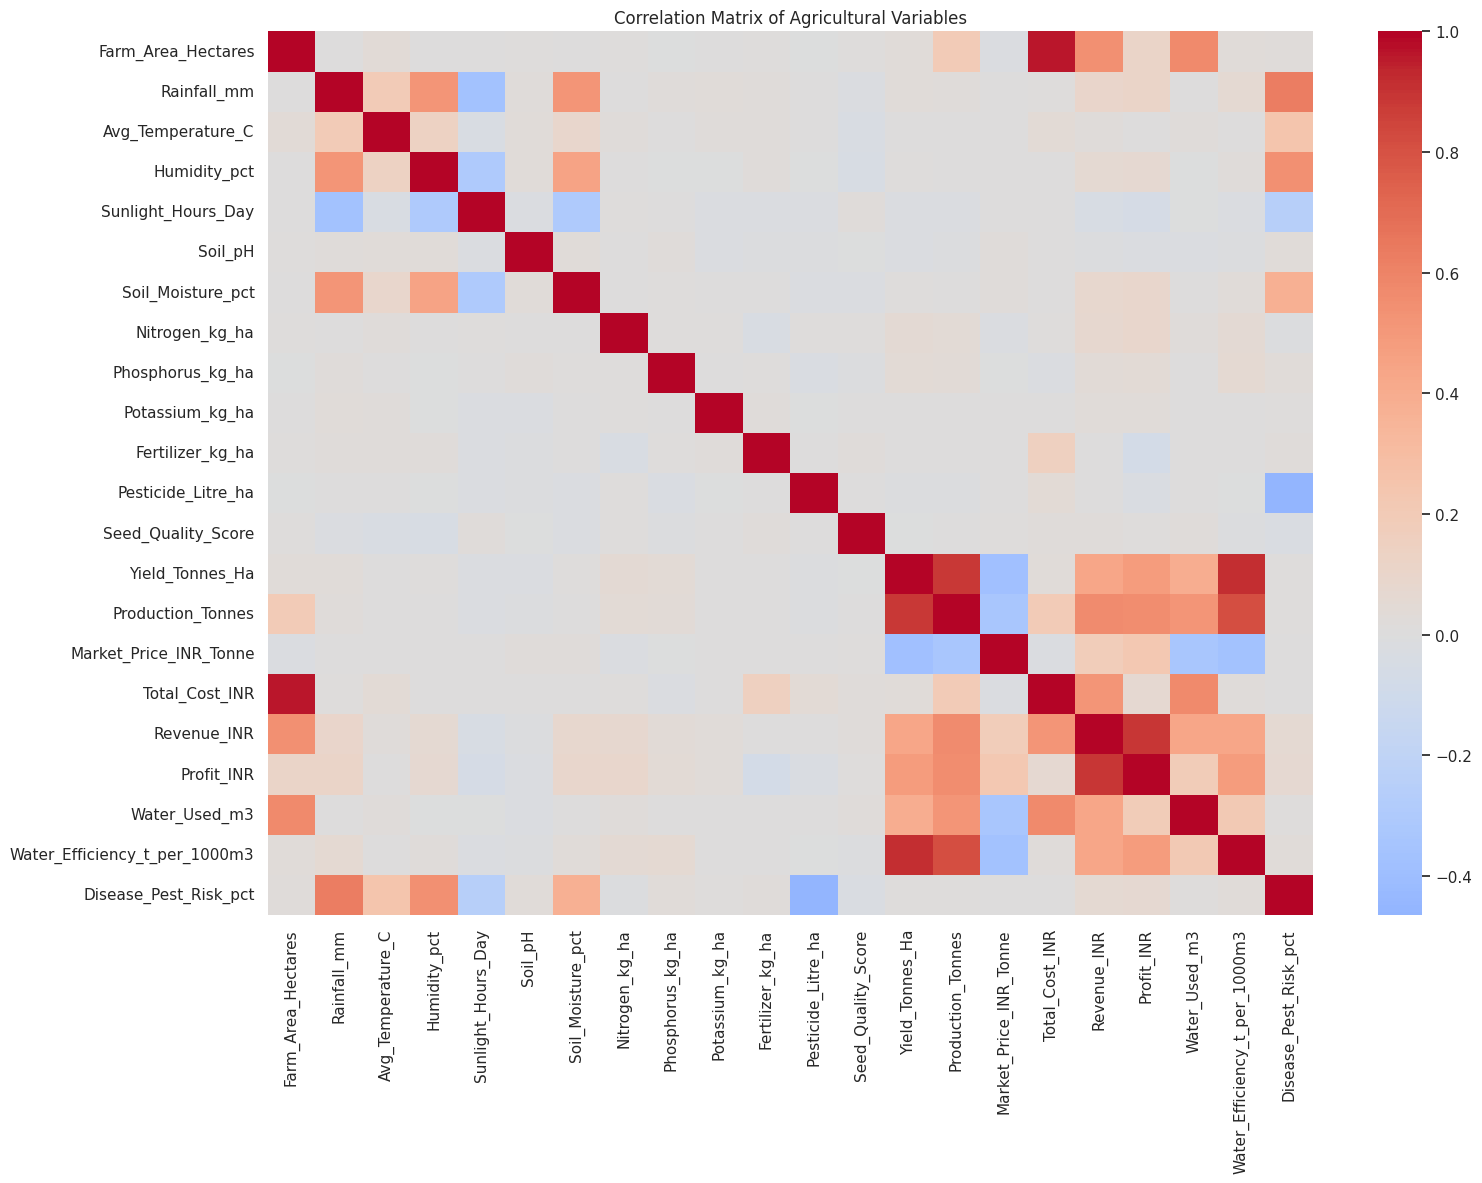

In [56]:
plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.tight_layout()
plt.show()

In [57]:
# ==========================================
# CORRELATION WITH YIELD
# ==========================================

yield_correlation = (
    correlation["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

yield_correlation

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.915438
Production_Tonnes,0.885171
Profit_INR,0.489822
Revenue_INR,0.433648
Water_Used_m3,0.388653
Nitrogen_kg_ha,0.053867
Phosphorus_kg_ha,0.047821
Rainfall_mm,0.030853
Total_Cost_INR,0.030814


In [58]:
# ==========================================
# CORRELATION WITH PROFIT
# ==========================================

profit_correlation = (
    correlation["Profit_INR"]
    .sort_values(ascending=False)
)

profit_correlation

,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Yield_Tonnes_Ha,0.489822
Water_Efficiency_t_per_1000m3,0.489487
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Farm_Area_Hectares,0.115241
Rainfall_mm,0.108104
Soil_Moisture_pct,0.091757


In [59]:
# ==========================================
# ANOVA TEST FOR YIELD
# ==========================================

season_groups = [
    group["Yield_Tonnes_Ha"].dropna()
    for name, group in df.groupby("Season")
]

anova_yield = stats.f_oneway(*season_groups)

print("F-statistic:", anova_yield.statistic)
print("P-value:", anova_yield.pvalue)

if anova_yield.pvalue < 0.05:
    print("\nConclusion:")
    print("There is a statistically significant difference in yield across seasons.")
else:
    print("\nConclusion:")
    print("There is no statistically significant difference in yield across seasons.")

F-statistic: 1.4579589466621523
P-value: 0.23283549440109827

Conclusion:
There is no statistically significant difference in yield across seasons.


In [60]:
# ==========================================
# ANOVA TEST FOR PROFIT
# ==========================================

profit_groups = [
    group["Profit_INR"].dropna()
    for name, group in df.groupby("Season")
]

anova_profit = stats.f_oneway(*profit_groups)

print("F-statistic:", anova_profit.statistic)
print("P-value:", anova_profit.pvalue)

if anova_profit.pvalue < 0.05:
    print("\nConclusion:")
    print("There is a statistically significant difference in profit across seasons.")
else:
    print("\nConclusion:")
    print("There is no statistically significant difference in profit across seasons.")

F-statistic: 34.29175033935195
P-value: 1.7124156677360182e-15

Conclusion:
There is a statistically significant difference in profit across seasons.


In [62]:
# ==========================================
# OUTLIER DETECTION FOR YIELD
# ==========================================

Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

yield_outliers = df[
    (df["Yield_Tonnes_Ha"] < lower_bound) |
    (df["Yield_Tonnes_Ha"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of Yield Outliers:",
      len(yield_outliers))

Lower Bound: -1.6349999999999996
Upper Bound: 5.5249999999999995

Number of Yield Outliers: 302


In [63]:
# ==========================================
# PROFIT MARGIN
# ==========================================

df["Profit_Margin_pct"] = np.where(
    df["Revenue_INR"] != 0,
    (df["Profit_INR"] / df["Revenue_INR"]) * 100,
    0
)

df[
    [
        "Revenue_INR",
        "Total_Cost_INR",
        "Profit_INR",
        "Profit_Margin_pct"
    ]
].head()

,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct
0,30810,42662,-11852,-38.468030
1,40401,492351,-451950,-1118.660429
2,190466,315210,-124744,-65.494104
3,200740,296444,-95704,-47.675600
4,193607,337959,-144352,-74.559288


In [64]:
# ==========================================
# PROFIT MARGIN BY SEASON
# ==========================================

profit_margin = (
    df.groupby("Season")["Profit_Margin_pct"]
    .mean()
    .sort_values(ascending=False)
)

profit_margin

,Profit_Margin_pct
Season,
Kharif,-38.644541
Rabi,-44.267645
Zaid,-69.354573


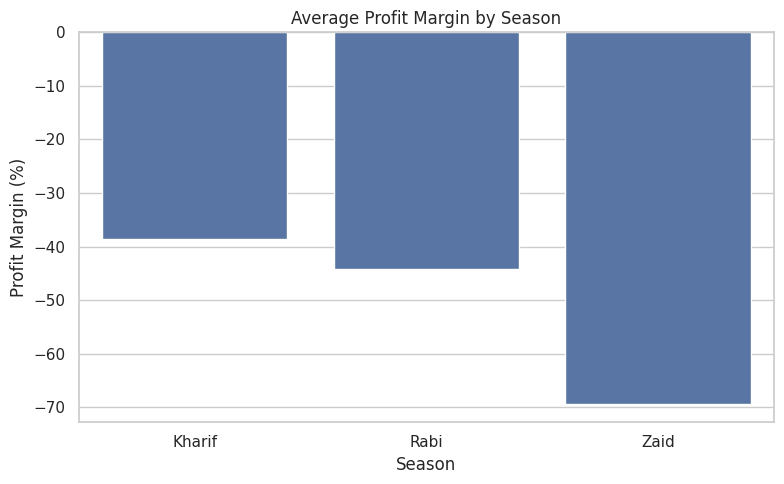

In [65]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_margin.index,
    y=profit_margin.values
)

plt.title("Average Profit Margin by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

In [66]:
# ==========================================
# STATE-WISE PERFORMANCE
# ==========================================

state_performance = df.groupby("State").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

state_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
State,,,,,,
Andhra Pradesh,4.65,36.91,606663.66,73453.53,5.03,46.72
Gujarat,5.70,48.33,654692.86,117568.24,5.58,45.95
Karnataka,5.73,47.73,653426.18,119422.34,5.56,46.06
Madhya Pradesh,5.03,37.56,597558.36,86840.76,5.27,47.08
Maharashtra,5.03,43.98,650032.67,135428.86,5.28,46.44
Punjab,6.12,52.23,686225.70,136025.64,5.62,46.00
Tamil Nadu,4.90,40.84,629093.42,117744.75,5.31,46.28
Telangana,5.08,39.25,628784.53,108829.62,5.46,46.36


In [67]:
# ==========================================
# TOP 10 STATES BY YIELD
# ==========================================

top_states = (
    state_performance
    .sort_values("Yield_Tonnes_Ha", ascending=False)
    .head(10)
)

top_states

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
State,,,,,,
Punjab,6.12,52.23,686225.70,136025.64,5.62,46.00
Karnataka,5.73,47.73,653426.18,119422.34,5.56,46.06
Gujarat,5.70,48.33,654692.86,117568.24,5.58,45.95
Telangana,5.08,39.25,628784.53,108829.62,5.46,46.36
Maharashtra,5.03,43.98,650032.67,135428.86,5.28,46.44
Madhya Pradesh,5.03,37.56,597558.36,86840.76,5.27,47.08
Tamil Nadu,4.90,40.84,629093.42,117744.75,5.31,46.28
Andhra Pradesh,4.65,36.91,606663.66,73453.53,5.03,46.72


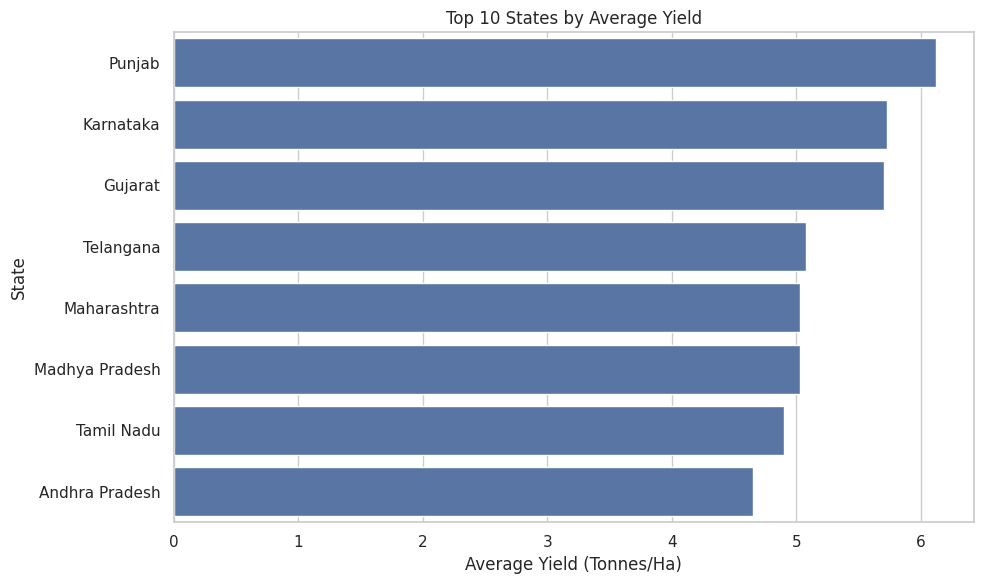

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_states.reset_index(),
    x="Yield_Tonnes_Ha",
    y="State"
)

plt.title("Top 10 States by Average Yield")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

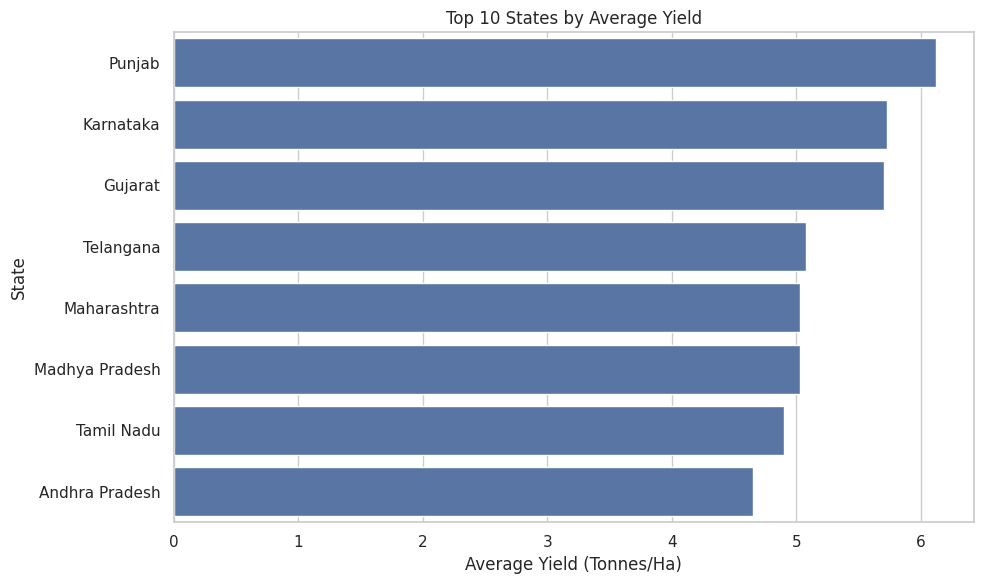

In [69]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_states.reset_index(),
    x="Yield_Tonnes_Ha",
    y="State"
)

plt.title("Top 10 States by Average Yield")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [70]:
# ==========================================
# CROP PERFORMANCE
# ==========================================

crop_performance = df.groupby("Crop").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean"
}).round(2)

crop_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Crop,,,,
Chilli,1.54,12.38,1276777.23,750878.34
Cotton,1.23,9.40,639423.08,124546.92
Groundnut,1.32,9.66,542935.50,44858.12
Maize,2.72,21.78,457067.99,-83978.33
Pulses,0.92,7.40,528465.87,-4238.05
Rice,2.44,19.29,423615.26,-102213.50
Sugarcane,46.94,392.41,1371980.11,817187.99
Wheat,2.11,16.85,400104.89,-123398.34


In [71]:
# ==========================================
# TOP CROPS BY YIELD
# ==========================================

top_crops_yield = (
    crop_performance
    .sort_values("Yield_Tonnes_Ha", ascending=False)
    .head(10)
)

top_crops_yield

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Crop,,,,
Sugarcane,46.94,392.41,1371980.11,817187.99
Maize,2.72,21.78,457067.99,-83978.33
Rice,2.44,19.29,423615.26,-102213.50
Wheat,2.11,16.85,400104.89,-123398.34
Chilli,1.54,12.38,1276777.23,750878.34
Groundnut,1.32,9.66,542935.50,44858.12
Cotton,1.23,9.40,639423.08,124546.92
Pulses,0.92,7.40,528465.87,-4238.05


In [72]:
# ==========================================
# TOP CROPS BY PROFIT
# ==========================================

top_crops_profit = (
    crop_performance
    .sort_values("Profit_INR", ascending=False)
    .head(10)
)

top_crops_profit

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Crop,,,,
Sugarcane,46.94,392.41,1371980.11,817187.99
Chilli,1.54,12.38,1276777.23,750878.34
Cotton,1.23,9.40,639423.08,124546.92
Groundnut,1.32,9.66,542935.50,44858.12
Pulses,0.92,7.40,528465.87,-4238.05
Maize,2.72,21.78,457067.99,-83978.33
Rice,2.44,19.29,423615.26,-102213.50
Wheat,2.11,16.85,400104.89,-123398.34


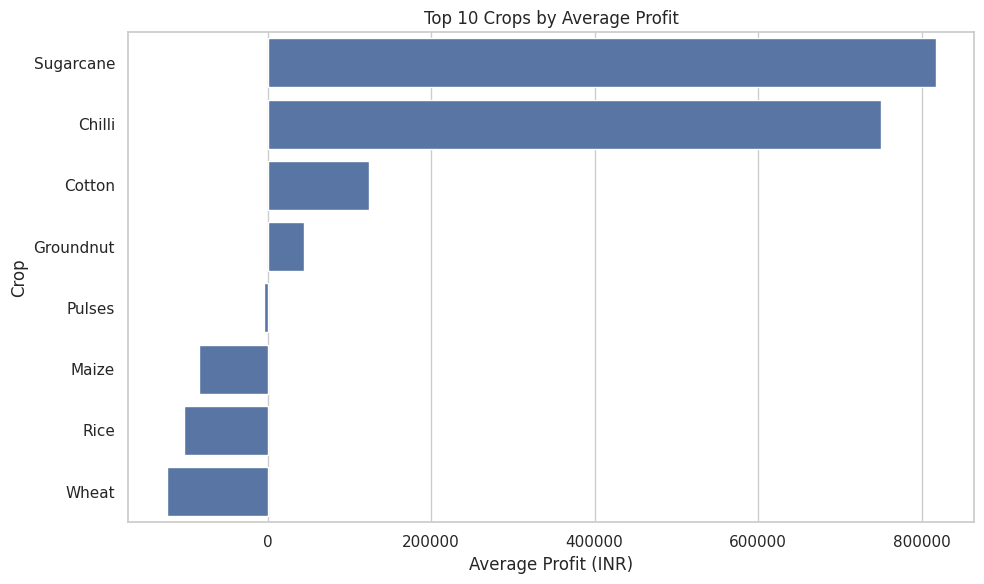

In [73]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_crops_profit.reset_index(),
    x="Profit_INR",
    y="Crop"
)

plt.title("Top 10 Crops by Average Profit")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [78]:
# ==========================================
# AUTOMATIC KEY RESULTS
# ==========================================

# Combine seasonal metrics into a single DataFrame
season_summary = pd.DataFrame({
    "Average_Yield": yield_by_season,
    "Average_Profit": profit_by_season,
    "Average_Water_Efficiency": water_efficiency,
    "Average_Disease_Risk": risk
})

best_yield_season = season_summary[
    "Average_Yield"
].idxmax()

best_profit_season = season_summary[
    "Average_Profit"
].idxmax()

best_water_season = season_summary[
    "Average_Water_Efficiency"
].idxmax()

lowest_risk_season = season_summary[
    "Average_Disease_Risk"
].idxmin()

best_yield_crop = crop_performance[
    "Yield_Tonnes_Ha"
].idxmax()

best_profit_crop = crop_performance[
    "Profit_INR"
].idxmax()

best_state = state_performance[
    "Yield_Tonnes_Ha"
].idxmax()


print("========== KEY RESULTS ==========\n")

print("Highest average yield season:",
      best_yield_season)

print("Highest average profit season:",
      best_profit_season)

print("Highest water efficiency season:",
      best_water_season)

print("Lowest disease/pest risk season:",
      lowest_risk_season)

print("Highest yielding crop:",
      best_yield_crop)

print("Most profitable crop:",
      best_profit_crop)

print("Highest average-yield state:",
      best_state)

========== KEY RESULTS ==========

Highest average yield season: Kharif
Highest average profit season: Kharif
Highest water efficiency season: Kharif
Lowest disease/pest risk season: Zaid
Highest yielding crop: Sugarcane
Most profitable crop: Sugarcane
Highest average-yield state: Punjab


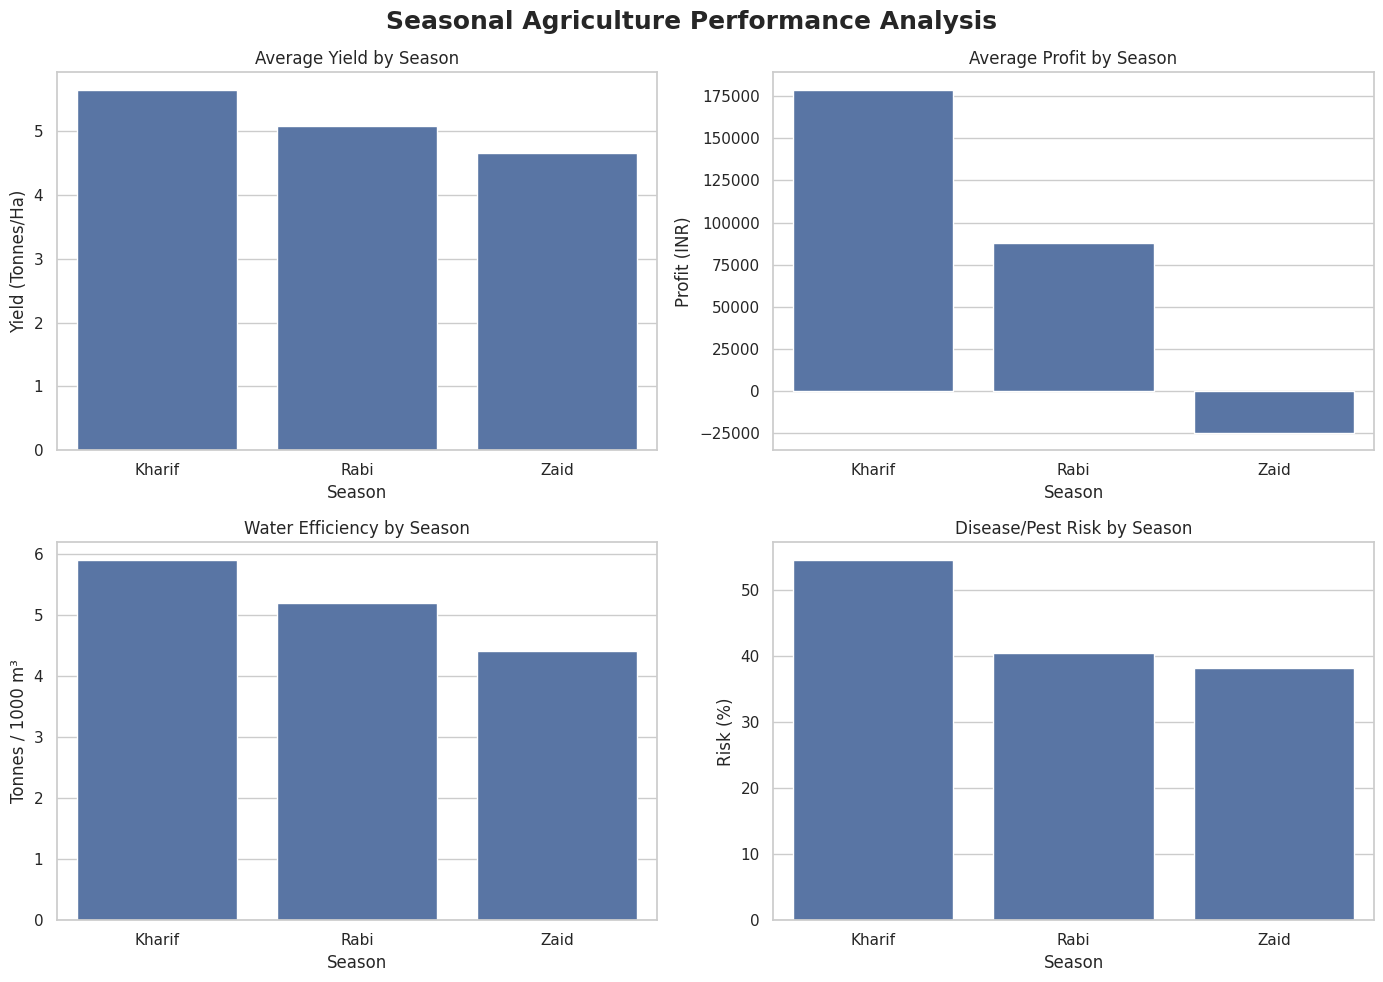

In [79]:
# ==========================================
# FINAL SEASONAL DASHBOARD
# ==========================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(14,10)
)

# ------------------------------------------
# Yield
# ------------------------------------------

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None,
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Average Yield by Season"
)

axes[0,0].set_xlabel("Season")
axes[0,0].set_ylabel(
    "Yield (Tonnes/Ha)"
)


# ------------------------------------------
# Profit
# ------------------------------------------

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    estimator="mean",
    errorbar=None,
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Average Profit by Season"
)

axes[0,1].set_xlabel("Season")
axes[0,1].set_ylabel(
    "Profit (INR)"
)


# ------------------------------------------
# Water Efficiency
# ------------------------------------------

sns.barplot(
    data=df,
    x="Season",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean",
    errorbar=None,
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Water Efficiency by Season"
)

axes[1,0].set_xlabel("Season")
axes[1,0].set_ylabel(
    "Tonnes / 1000 m³"
)


# ------------------------------------------
# Disease Risk
# ------------------------------------------

sns.barplot(
    data=df,
    x="Season",
    y="Disease_Pest_Risk_pct",
    estimator="mean",
    errorbar=None,
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Disease/Pest Risk by Season"
)

axes[1,1].set_xlabel("Season")
axes[1,1].set_ylabel(
    "Risk (%)"
)


fig.suptitle(
    "Seasonal Agriculture Performance Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [80]:
# ==========================================
# EXPORT RESULTS
# ==========================================

df.to_csv(
    "cleaned_seasonal_agriculture_dataset.csv",
    index=False
)

season_summary.to_csv(
    "seasonal_performance_summary.csv"
)

crop_performance.to_csv(
    "crop_performance_summary.csv"
)

state_performance.to_csv(
    "state_performance_summary.csv"
)

print("All result files have been created successfully.")

All result files have been created successfully.


# 19. Conclusion

The Seasonal Agriculture Performance Analysis was conducted to understand
how agricultural performance changes across different seasons.

The analysis examined agricultural yield, production, environmental
conditions, resource usage, economic performance, crop performance,
and disease/pest risk.

The seasonal comparison helped identify differences in average yield,
profitability, water efficiency, and disease/pest risk across seasons.

Correlation analysis was used to investigate relationships between
agricultural performance and factors such as rainfall, temperature,
soil moisture, fertilizer usage, and disease/pest risk.

Statistical analysis was also performed to determine whether observed
differences in yield and profit across seasons were statistically
significant.

Based on the analysis, the results can support evidence-based seasonal
agricultural planning, resource management, crop selection, and
risk management.

In [10]:
print("Dataset Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Crops:", df["Crop"].nunique())
print("States:", df["State"].nunique())
print("Districts:", df["District"].nunique())
print("Seasons:", df["Season"].nunique())

Dataset Shape: (4000, 28)
Total Missing Values: 120
Duplicate Rows: 0
Crops: 8
States: 8
Districts: 10
Seasons: 3


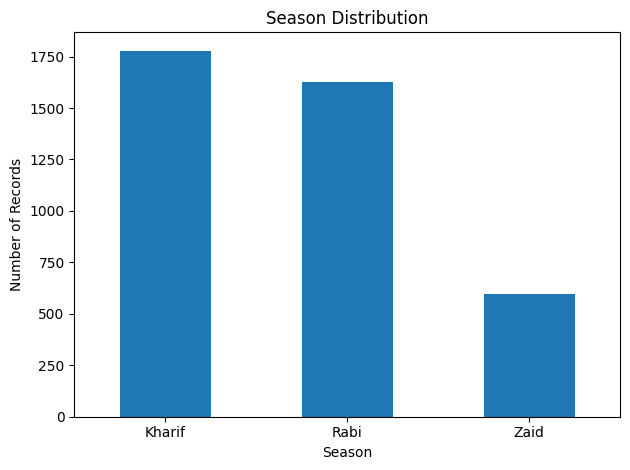

In [11]:
import matplotlib.pyplot as plt

df["Season"].value_counts().plot(kind="bar")

plt.title("Season Distribution")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

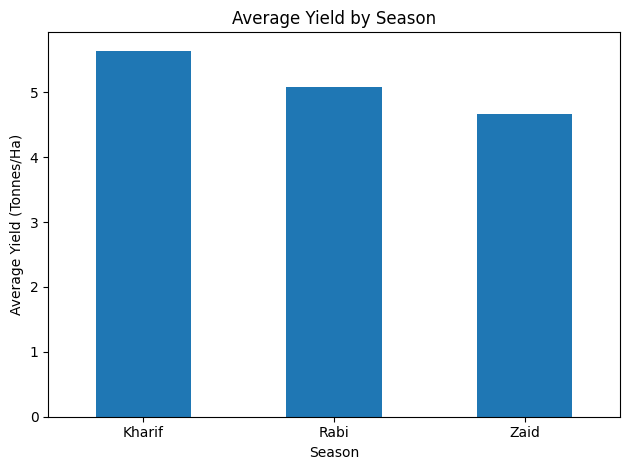

In [12]:
df.groupby("Season")["Yield_Tonnes_Ha"].mean().plot(
    kind="bar"
)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
print("Dataset Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Crops:", df["Crop"].nunique())
print("States:", df["State"].nunique())
print("Districts:", df["District"].nunique())
print("Seasons:", df["Season"].nunique())

NameError: name 'df' is not defined

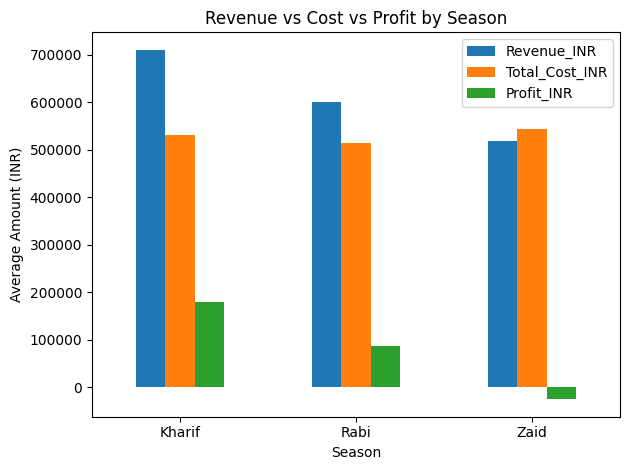

In [13]:
df.groupby("Season")[[
    "Revenue_INR",
    "Total_Cost_INR",
    "Profit_INR"
]].mean().plot(kind="bar")

plt.title("Revenue vs Cost vs Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Amount (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

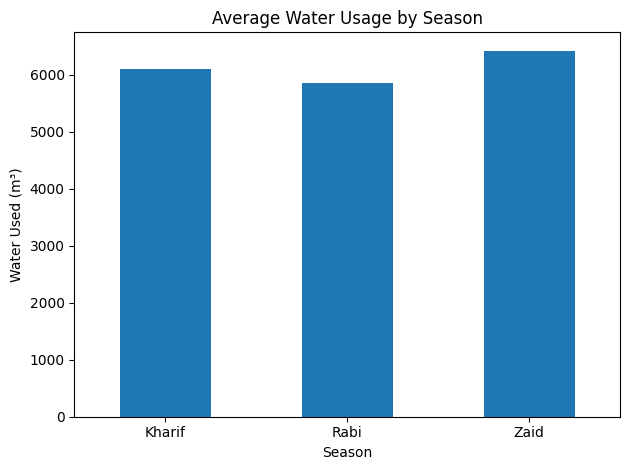

In [14]:
df.groupby("Season")["Water_Used_m3"].mean().plot(
    kind="bar"
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

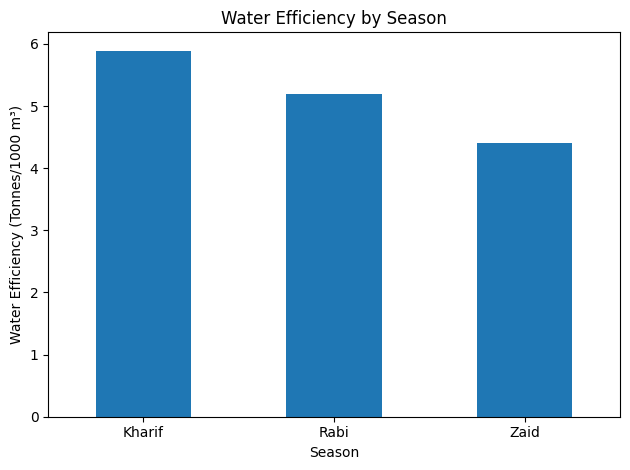

In [15]:
df.groupby("Season")[
    "Water_Efficiency_t_per_1000m3"
].mean().plot(kind="bar")

plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes/1000 m³)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

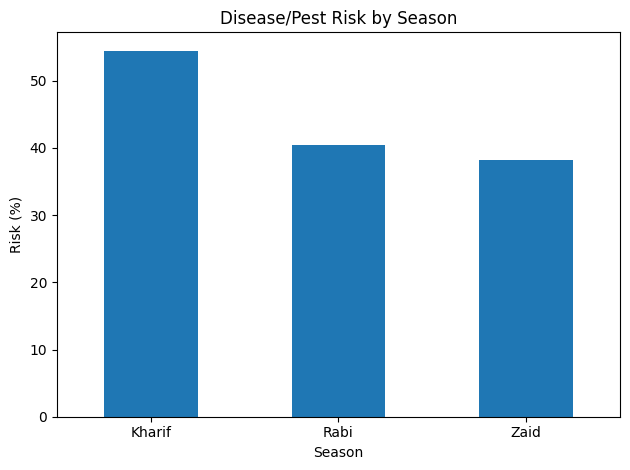

In [16]:
df.groupby("Season")[
    "Disease_Pest_Risk_pct"
].mean().plot(kind="bar")

plt.title("Disease/Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

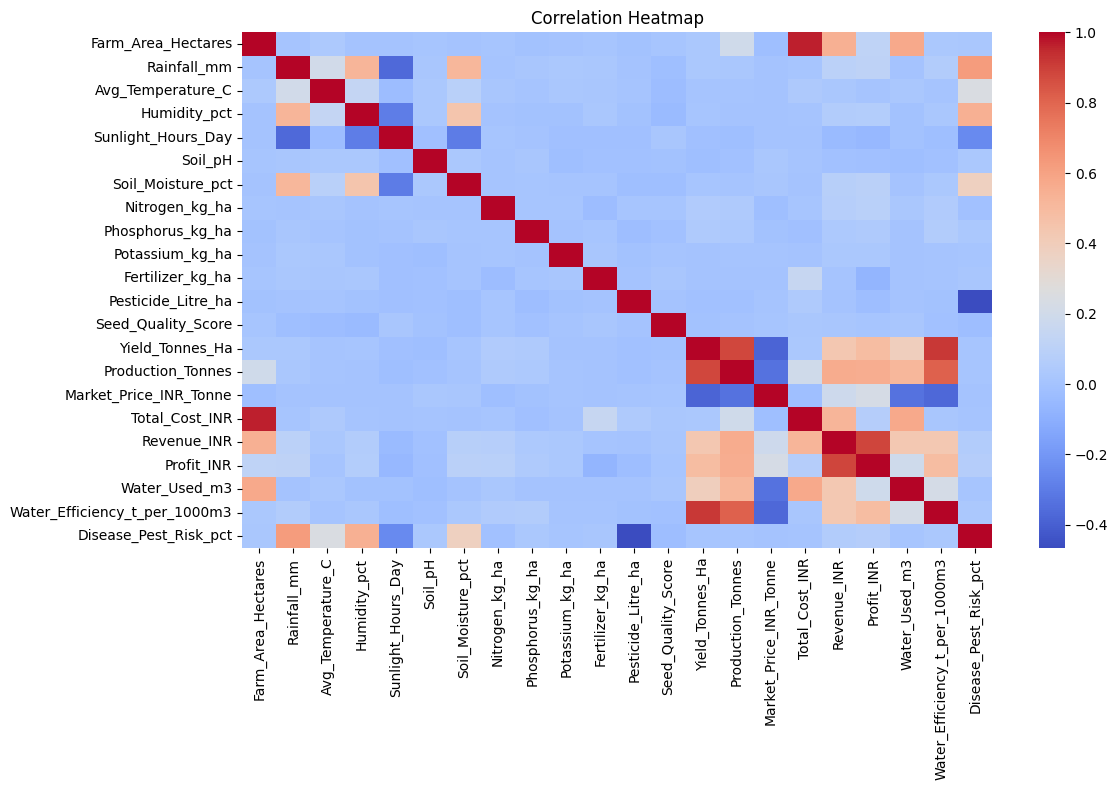

In [17]:
import seaborn as sns

plt.figure(figsize=(12,8))

corr = df.select_dtypes("number").corr()

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

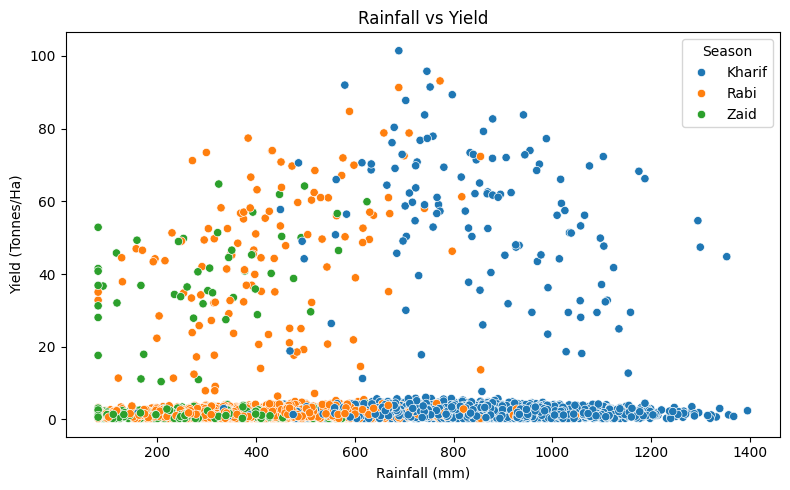

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# OVERALL RESULTS FOR PPT
# ============================================================

print("=" * 65)
print("        SEASONAL AGRICULTURE PERFORMANCE ANALYSIS")
print("                  OVERALL RESULTS")
print("=" * 65)

# Dataset Overview
print("\n1. DATASET OVERVIEW")
print("-" * 40)
print("Total Records      :", df.shape[0])
print("Total Attributes   :", df.shape[1])
print("Crops              :", df["Crop"].nunique())
print("States             :", df["State"].nunique())
print("Districts          :", df["District"].nunique())
print("Seasons            :", df["Season"].nunique())
print("Duplicate Records  :", df.duplicated().sum())
print("Missing Values     :", df.isnull().sum().sum())

# Season Distribution
print("\n2. SEASON DISTRIBUTION")
print("-" * 40)
print(df["Season"].value_counts())

# Seasonal Performance
print("\n3. SEASONAL PERFORMANCE")
print("-" * 40)

season = df.groupby("Season").agg(
    Yield=("Yield_Tonnes_Ha", "mean"),
    Production=("Production_Tonnes", "mean"),
    Revenue=("Revenue_INR", "mean"),
    Cost=("Total_Cost_INR", "mean"),
    Profit=("Profit_INR", "mean"),
    Water_Used=("Water_Used_m3", "mean"),
    Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

print(season)

# Best and Lowest Seasons
print("\n4. KEY FINDINGS")
print("-" * 40)

best_yield = season["Yield"].idxmax()
lowest_yield = season["Yield"].idxmin()
best_profit = season["Profit"].idxmax()
highest_water = season["Water_Used"].idxmax()
best_efficiency = season["Water_Efficiency"].idxmax()

print("Highest Average Yield       :", best_yield,
      "(", season.loc[best_yield, "Yield"], "tonnes/ha )")

print("Lowest Average Yield        :", lowest_yield,
      "(", season.loc[lowest_yield, "Yield"], "tonnes/ha )")

print("Highest Average Profit      :", best_profit,
      "(₹", season.loc[best_profit, "Profit"], ")")

print("Highest Water Usage         :", highest_water,
      "(", season.loc[highest_water, "Water_Used"], "m³ )")

print("Highest Water Efficiency    :", best_efficiency,
      "(", season.loc[best_efficiency, "Water_Efficiency"], ")")

# Correlation
print("\n5. TOP CORRELATIONS WITH YIELD")
print("-" * 40)

corr = df.select_dtypes("number").corr()["Yield_Tonnes_Ha"]
corr = corr.drop("Yield_Tonnes_Ha").sort_values(ascending=False)

print(corr.head(5).round(3))

# ANOVA
print("\n6. ANOVA - YIELD ACROSS SEASONS")
print("-" * 40)

data = df.dropna(subset=["Yield_Tonnes_Ha"])

groups = [
    data[data["Season"] == "Kharif"]["Yield_Tonnes_Ha"],
    data[data["Season"] == "Rabi"]["Yield_Tonnes_Ha"],
    data[data["Season"] == "Zaid"]["Yield_Tonnes_Ha"]
]

from scipy.stats import f_oneway

f, p = f_oneway(*groups)

print("F-statistic :", round(f, 3))
print("p-value     :", round(p, 3))

if p < 0.05:
    print("Conclusion  : Significant difference")
else:
    print("Conclusion  : No statistically significant difference")

print("\n" + "=" * 65)
print("                    END OF RESULTS")
print("=" * 65)

        SEASONAL AGRICULTURE PERFORMANCE ANALYSIS
                  OVERALL RESULTS

1. DATASET OVERVIEW
----------------------------------------
Total Records      : 4000
Total Attributes   : 28
Crops              : 8
States             : 8
Districts          : 10
Seasons            : 3
Duplicate Records  : 0
Missing Values     : 120

2. SEASON DISTRIBUTION
----------------------------------------
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

3. SEASONAL PERFORMANCE
----------------------------------------
        Yield  Production    Revenue       Cost     Profit  Water_Used  \
Season                                                                   
Kharif   5.64       46.31  710719.06  531804.41  178914.65     6102.20   
Rabi     5.08       41.49  601526.05  513836.58   87689.47     5846.99   
Zaid     4.67       38.89  519171.90  543976.73  -24804.82     6419.89   

        Water_Efficiency  Disease_Risk  
Season                                  
K